In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv(r"C:\Users\sangi\OneDrive\Desktop\google_colab\Airbnb_NewYorkCity_Analysis\data\Airbnb.csv")
df.head(1)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.68371,-73.96461,Private room,55.0,...,20-12-2015,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified


In [33]:
df.shape

(20770, 22)

In [34]:
df.dropna(inplace=True)

In [35]:
df.shape

(20736, 22)

In [26]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'] .quantile(0.75)
IQR = Q1 - Q3
print(IQR)

-119.0


In [28]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

258.5
20.5


In [36]:
# converting string to float values
df['rating']= df['rating'].astype(str)

In [37]:
df.shape

(20736, 22)

In [38]:
# extracting only numbers
df['rating']= df['rating'].str.extract(r"(\d+\.?\d*)")
#changing to numeric column
df['rating'] =  pd.to_numeric(df['rating'], errors='coerce')

In [39]:
# filling null values with median
df['rating'].fillna(df['rating'].median(), inplace=True)

C:\Users\sangi\AppData\Local\Temp\ipykernel_12860\1221712844.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)


In [41]:
df['rating'].shape
df['price'].shape

(20736,)

In [50]:
df['rating'].isnull().sum()

np.int64(0)

In [49]:
df['price'].isnull().sum()

np.int64(0)

In [61]:
from sklearn.model_selection import train_test_split

X = df['rating']
y = df['price']
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

In [62]:
X_train.shape[0]

16588

In [63]:
y_train.shape[0]

16588

In [64]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)



In [66]:
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MAE: 114.04414360315702
R2 Score: -0.008938164041408792


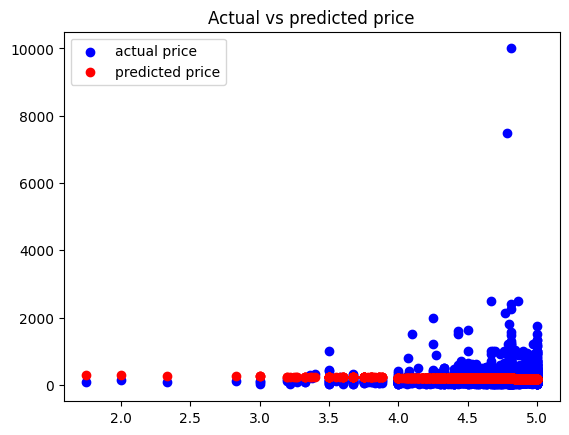

In [68]:
plt.scatter(x=X_test, y=y_test, color='blue', label= 'actual price')
plt.scatter(x=X_test, y=y_pred, color='red', label= 'predicted price')
plt.legend()
plt.title('Actual vs predicted price')
plt.show()